In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)
import pickle
import warnings


In [2]:
df = pd.read_csv('D:\Customer-Churn-Records.csv')


In [3]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,0,1,DIAMOND,300
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,0,5,PLATINUM,771
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,1,3,SILVER,564
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,1,2,GOLD,339


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [5]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain',
       'Satisfaction Score', 'Card Type', 'Point Earned'],
      dtype='object')

In [6]:
df = df.drop(['CustomerId'],axis =1)
df = df.drop(['Surname'],axis =1)
df = df.drop(['Complain'],axis =1)
df = df.drop(['RowNumber'],axis =1)


In [7]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,5,GOLD,425


In [8]:
df.isnull().sum()

CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

<Axes: ylabel='Exited'>

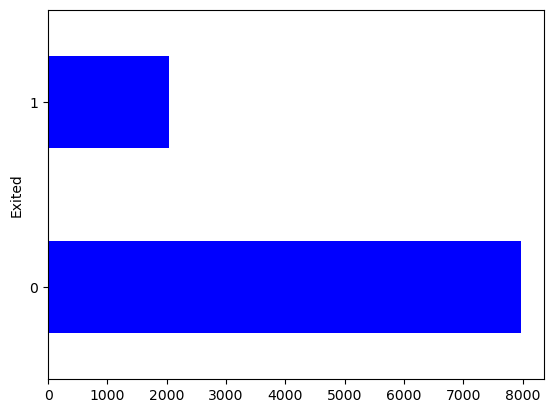

In [9]:
df['Exited'].value_counts().plot(kind = 'barh', color='blue')

In [10]:
#The number of people exited are not much but we gotta analyse the records of customers who churned/exited

In [11]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Point Earned
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,3.013800,606.515100
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,1.405919,225.924839
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,1.000000,119.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,2.000000,410.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,3.000000,605.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,4.000000,801.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,5.000000,1000.000000


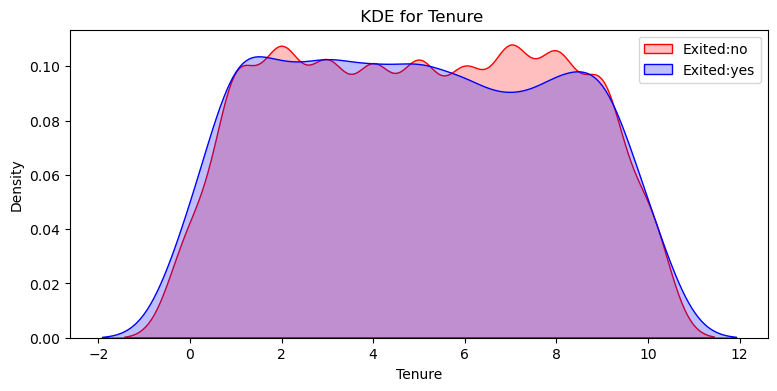

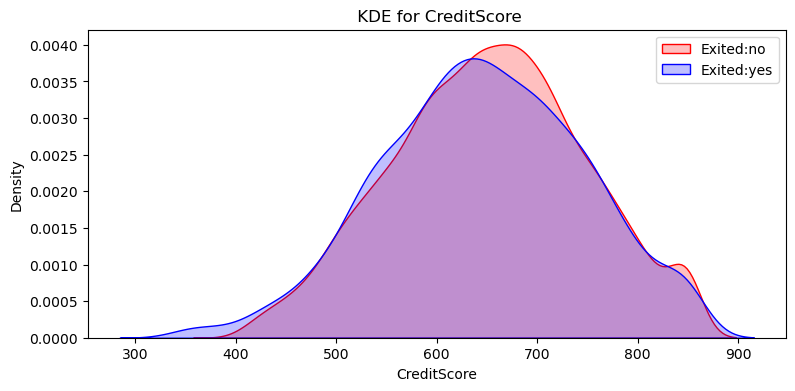

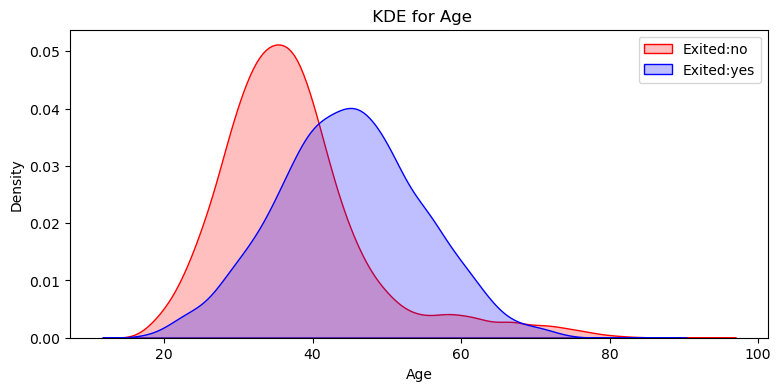

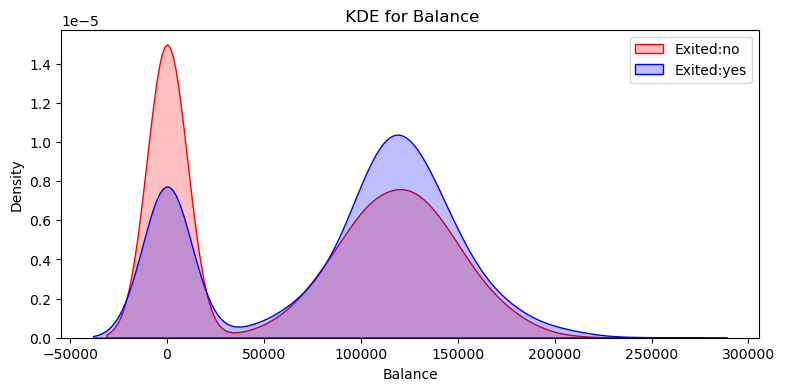

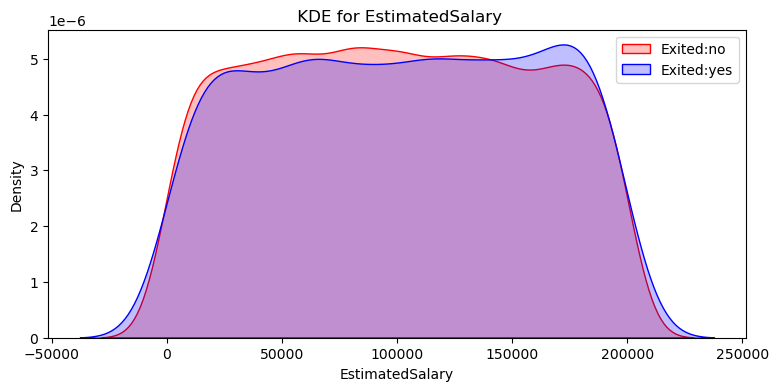

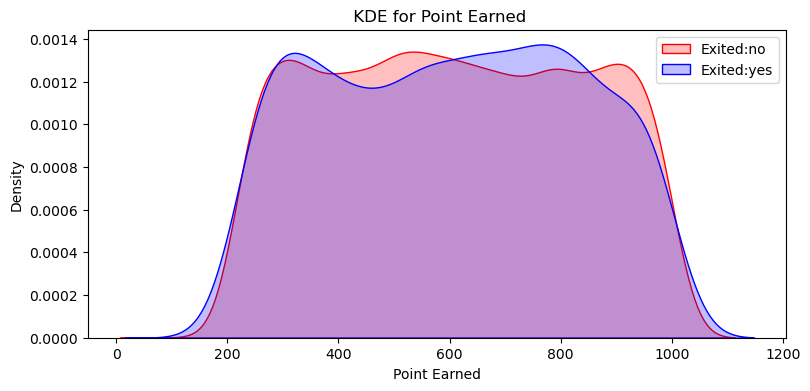

In [12]:
def kdeplot(feature):
    plt.figure(figsize=(9,4))
    plt.title(f" KDE for {feature}")

    ax0= sns.kdeplot(df[df['Exited'] == 0] [feature].dropna(),color='red', label = 'Exited:no',fill = True)
    ax1= sns.kdeplot(df[df['Exited'] == 1] [feature].dropna(),color='blue', label = 'Exited:yes',fill = True)

    plt.legend()
    plt.show()

for col in ['Tenure', 'CreditScore', 'Age', 'Balance', 'EstimatedSalary', 'Point Earned']:
        kdeplot(col)

    

In [13]:
#1.Tenure - there's a little drop in customers in between the tenure of year 6-9
#2.Age - People in the ages 40-50 are churning more in comparision to others
#3. Balance - people with balance between 100000 and 150000 are churning more in comparision to others
#4. Other catogories don't have much differnce in churning

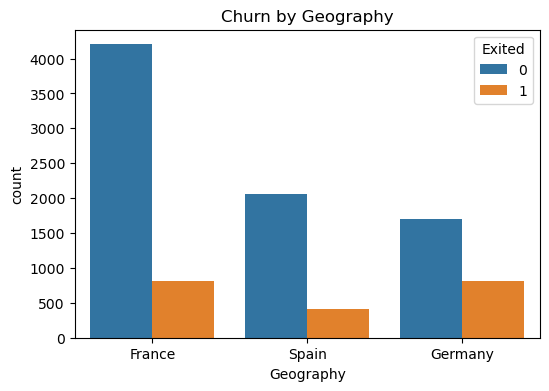

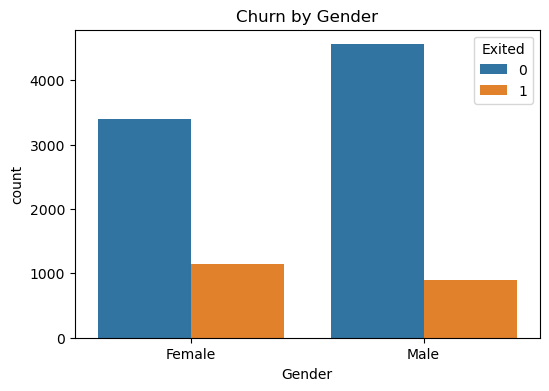

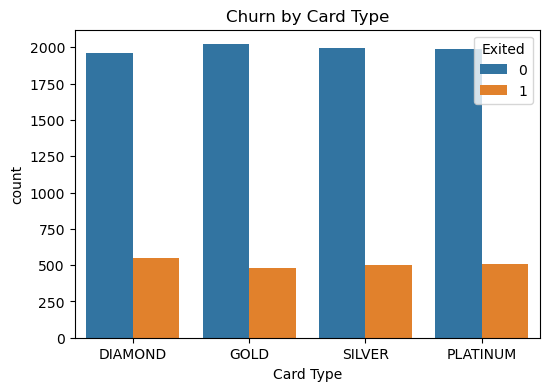

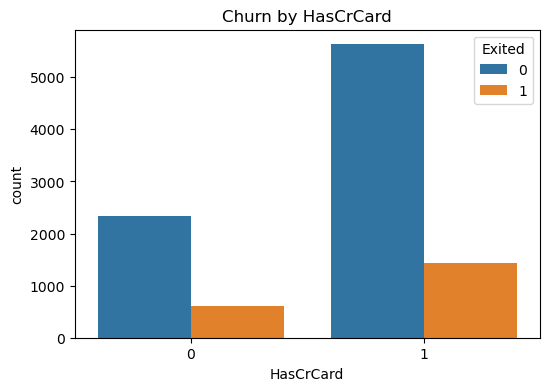

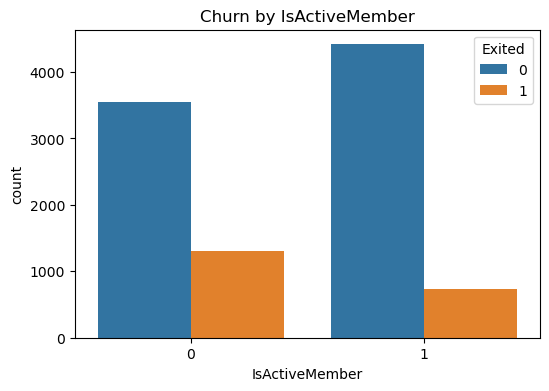

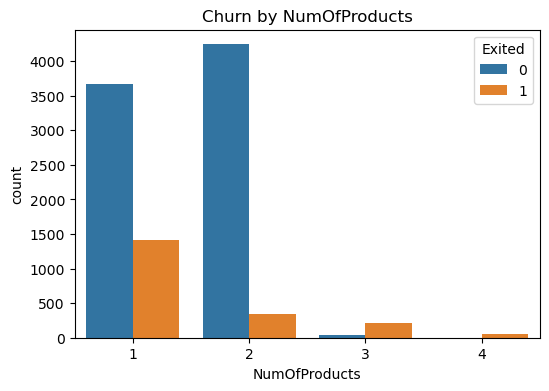

In [14]:
for col in ['Geography', 'Gender', 'Card Type', 'HasCrCard', 'IsActiveMember', 'NumOfProducts']:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='Exited', data=df)
    plt.title(f'Churn by {col}')
    plt.show()

In [15]:
#1.People in France and Germany are churning more
#2.Feamales are exiting more often
#3.people with credit card are leaving us too
#4. people having less number of products are bound to churn more
#5. also inactive members are leaving


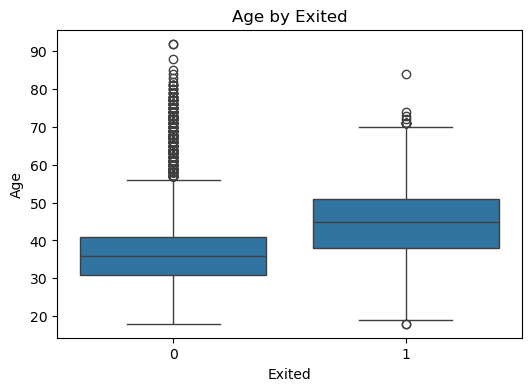

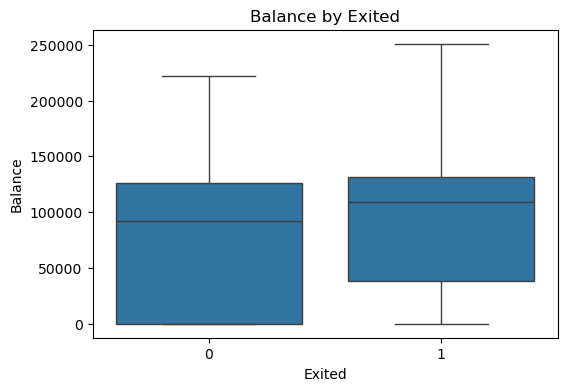

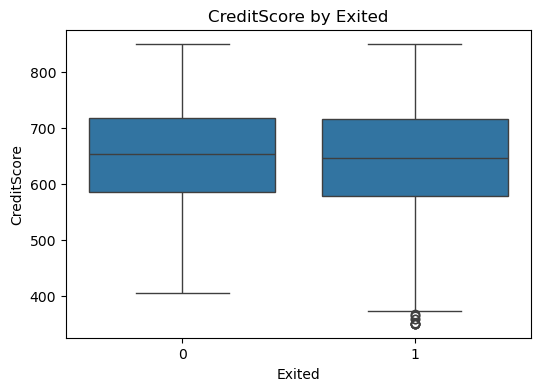

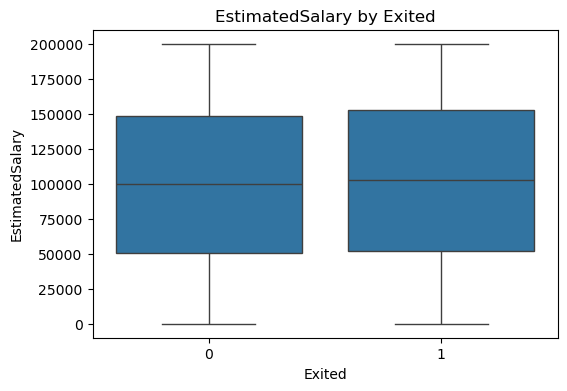

In [16]:
for col in ['Age', 'Balance', 'CreditScore', 'EstimatedSalary']:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Exited', y=col, data=df)
    plt.title(f'{col} by Exited')
    plt.show()

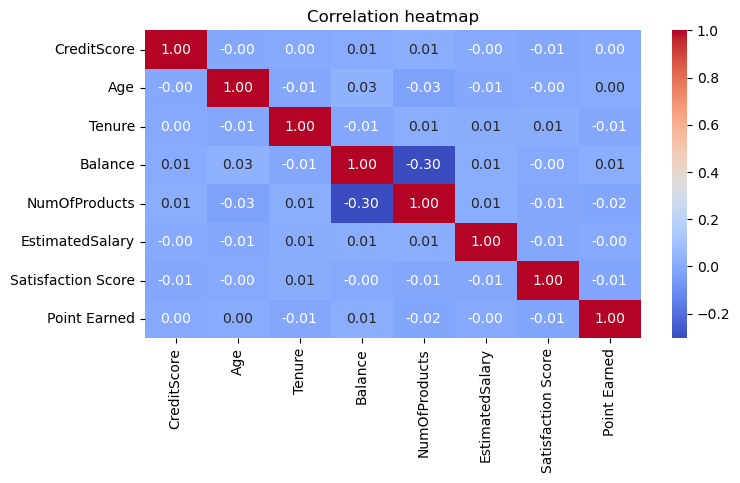

In [18]:
plt.figure(figsize=(8,4))
sns.heatmap(df[["CreditScore","Age","Tenure","Balance","NumOfProducts","EstimatedSalary","Satisfaction Score","Point Earned"]].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation heatmap")
plt.show()


In [19]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,5,GOLD,425


In [20]:
df2 = pd.get_dummies(data=df, columns=['Geography', 'Card Type','Gender'], dtype=int)
df2.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Point Earned,Geography_France,Geography_Germany,Geography_Spain,Card Type_DIAMOND,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER,Gender_Female,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,2,464,1,0,0,1,0,0,0,1,0
1,608,41,1,83807.86,1,0,1,112542.58,0,3,456,0,0,1,1,0,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,3,377,1,0,0,1,0,0,0,1,0
3,699,39,1,0.00,2,0,0,93826.63,0,5,350,1,0,0,0,1,0,0,1,0
4,850,43,2,125510.82,1,1,1,79084.10,0,5,425,0,0,1,0,1,0,0,1,0


In [21]:
df2.dtypes

CreditScore             int64
Age                     int64
Tenure                  int64
Balance               float64
NumOfProducts           int64
HasCrCard               int64
IsActiveMember          int64
EstimatedSalary       float64
Exited                  int64
Satisfaction Score      int64
Point Earned            int64
Geography_France        int64
Geography_Germany       int64
Geography_Spain         int64
Card Type_DIAMOND       int64
Card Type_GOLD          int64
Card Type_PLATINUM      int64
Card Type_SILVER        int64
Gender_Female           int64
Gender_Male             int64
dtype: object

In [22]:
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'Satisfaction Score', 'Card Type', 'Point Earned'],
      dtype='object')

In [23]:
cols_to_scale = ['EstimatedSalary','Point Earned','CreditScore', 'Age', 'Tenure', 'Balance','NumOfProducts']

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df2[cols_to_scale] = scaler.fit_transform(df2[cols_to_scale])

In [24]:
#left for comment

In [25]:
X = df2.drop(columns = ['Exited'])
y = df2['Exited']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [27]:
print(y_train.value_counts())

Exited
0    6355
1    1645
Name: count, dtype: int64


In [28]:
smote = SMOTE( random_state = 42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [29]:
print(y_train_smote.value_counts())

Exited
0    6355
1    6355
Name: count, dtype: int64


In [ ]:
#  model_rf = RandomForestClassifier()        [Used this rf model to train first]
# model_rf.fit(X_train_smote, y_train_smote)

# accuracy_rf = model_rf.score(X_test, y_test)
# print('Random Forest Accuracy is: ', accuracy_rf)

# y_pred_rf = model_rf.predict(X_test) 



C:\Users\Rishi\AppData\Local\Temp\ipykernel_7292\3891420300.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importance_df['Importance'], y=feat_importance_df['Feature'], palette='viridis')


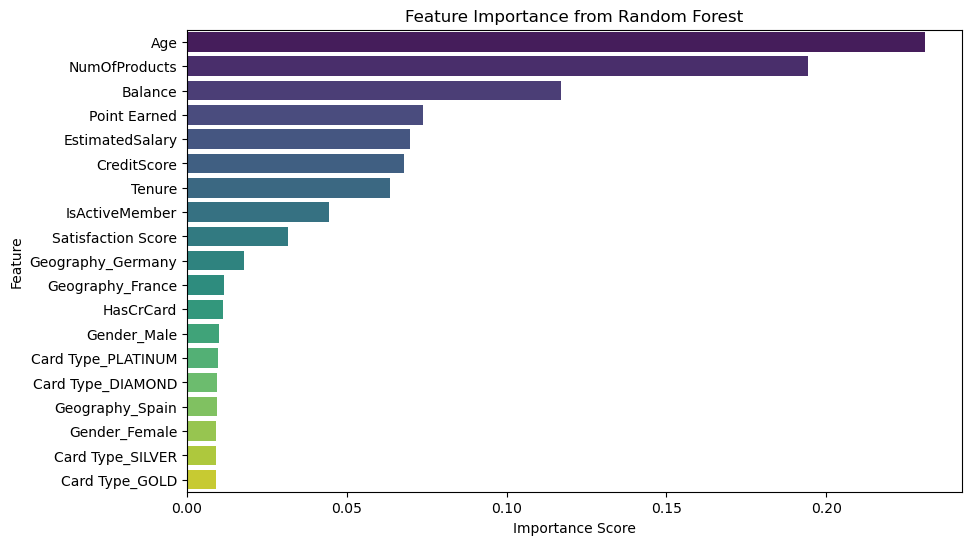

In [31]:
feature_importance = model_rf.feature_importances_ 

feat_importance_df = pd.DataFrame({'Feature': X_train_smote.columns, 'Importance': feature_importance})


feat_importance_df = feat_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feat_importance_df['Importance'], y=feat_importance_df['Feature'], palette='viridis')
plt.title('Feature Importance from Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

In [32]:



scale_pos_weight = (y_train_smote == 0).sum() / (y_train_smote == 1).sum()

xgb_model = XGBClassifier(n_estimators=500,max_depth=5,learning_rate=0.05, subsample=0.8,colsample_bytree=0.8,eval_metric='logloss',random_state=42,n_jobs=-1
)
xgb_model.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb_model.predict(X_test)
print("XGBoost Accuracy:", xgb_model.score(X_test, y_test))
print("XGBoost F1:", f1_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.865
XGBoost F1: 0.6186440677966102
